In [41]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Isolation Forest

In [42]:
df = pd.read_csv("/Users/sakshamchauhan/Downloads/Data_Science/Machine_Learning/PCA_&_Anomaly_Detection/healthcare_dataset.csv")
df.head()

,Patient_ID,Age,Gender,Blood_Pressure,Heart_Rate,Cholesterol_Level,BMI,Diagnosis,Treatment_Plan,Follow_Up_Date
0,1,51,Female,97,90,282,35.2,Hypertension,Observation,2024-01-01
1,2,92,Other,129,80,169,32.3,Healthy,Medication,2024-01-02
2,3,14,Male,172,76,157,29.9,Diabetes,Observation,2024-01-03
3,4,71,Female,131,82,150,19.4,Coronary Artery Disease,Surgery,2024-01-04
4,5,60,Male,130,96,206,39.3,Diabetes,NaN,2024-01-05


In [43]:
df.columns

Index(['Patient_ID', 'Age', 'Gender', 'Blood_Pressure', 'Heart_Rate',
       'Cholesterol_Level', 'BMI', 'Diagnosis', 'Treatment_Plan',
       'Follow_Up_Date'],
      dtype='str')

In [44]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

le = LabelEncoder()

df['Gender'] = le.fit_transform(df['Gender'])
df['Diagnosis'] = le.fit_transform(df['Diagnosis'])
df['Treatment_Plan'] = le.fit_transform(df['Treatment_Plan'])

scaler = StandardScaler()

num_cols = [
    'Age',
    'Blood_Pressure',
    'Heart_Rate',
    'Cholesterol_Level',
    'BMI'
]

df[num_cols] = scaler.fit_transform(df[num_cols])

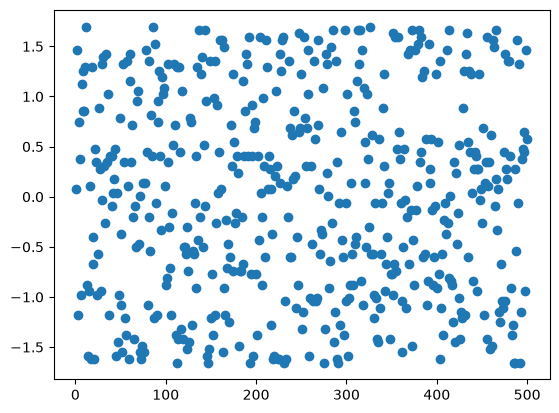

In [45]:
plt.scatter(df.iloc[:,0], df.iloc[:,1])

In [46]:
from sklearn.ensemble import IsolationForest

In [47]:
from sklearn.ensemble import IsolationForest

features = [
    'Age',
    'Blood_Pressure',
    'Heart_Rate',
    'Cholesterol_Level',
    'BMI',
    'Gender',
    'Diagnosis',
    'Treatment_Plan'
]

clf = IsolationForest(
    contamination=0.2,
    random_state=42
)

clf.fit(df[features])

predictions = clf.predict(df[features])

In [48]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = scaler.fit_transform(df[features])

In [49]:
from sklearn.ensemble import IsolationForest

clf = IsolationForest(
    contamination=0.1,
    random_state=42
)

clf.fit(X)

,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary <n_jobs>` for more details.",None
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary <warm_start>`... versionadded:: 0.21",False
Name,Type,Value
estimator_ estimator_: :class:`~sklearn.tree.ExtraTreeRegressor` instanceThe child estimator template used to create the collection offitted sub-estimators... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,ExtraTreeRegressor,ExtraTreeRegr...ndom_state=42)


In [50]:
predictions = clf.predict(X)

df['Anomaly'] = predictions

In [51]:
df[df['Anomaly'] == -1]

,Patient_ID,Age,Gender,Blood_Pressure,Heart_Rate,Cholesterol_Level,BMI,Diagnosis,Treatment_Plan,Follow_Up_Date,Anomaly
20,21,-1.620636,0,1.208133,0.187429,1.184204,0.370444,0,0,2024-01-21,-1
30,31,1.392202,0,-0.780980,0.187429,-1.442710,1.186544,4,4,2024-01-31,-1
44,45,-1.586784,1,-1.405016,1.157196,1.050632,-1.212790,3,0,2024-02-14,-1
46,47,-1.451376,2,0.272079,1.421678,-1.531758,0.762172,1,4,2024-02-16,-1
52,53,1.324498,2,0.935117,-1.487622,-1.598544,0.125614,0,2,2024-02-22,-1
71,72,-1.552932,2,-1.522023,0.716393,1.451348,0.158258,2,0,2024-03-12,-1
78,79,0.444343,2,-1.639029,-0.077052,-0.084729,-1.767737,0,0,2024-03-19,-1
80,81,1.358350,1,0.818111,-1.752104,-1.420448,-1.653483,4,4,2024-03-21,-1
87,88,1.527611,2,-0.780980,1.421678,1.228728,-0.706808,4,1,2024-03-28,-1
89,90,-1.180559,2,-0.351956,-1.752104,-1.286876,1.708848,0,3,2024-03-30,-1


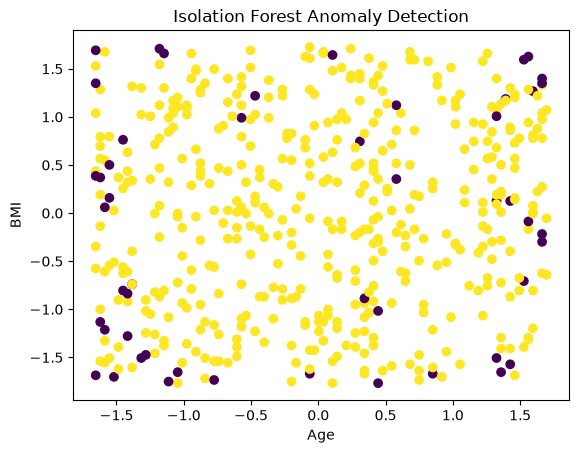

In [52]:
import matplotlib.pyplot as plt

plt.scatter(
    df['Age'],
    df['BMI'],
    c=df['Anomaly']
)

plt.xlabel('Age')
plt.ylabel('BMI')
plt.title('Isolation Forest Anomaly Detection')
plt.show()

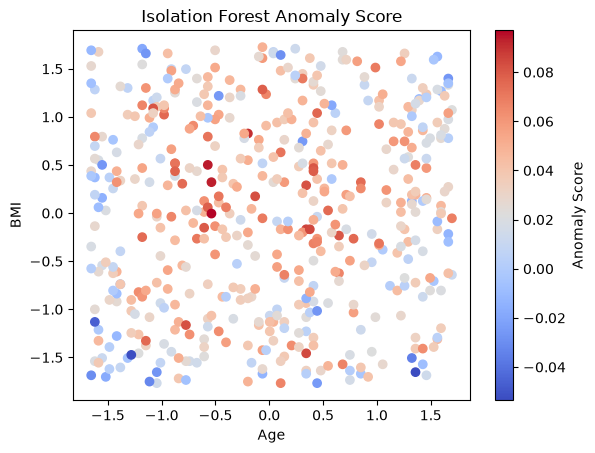

In [53]:
df['Anomaly_Score'] = clf.decision_function(X)

plt.scatter(
    df['Age'],
    df['BMI'],
    c=df['Anomaly_Score'],
    cmap='coolwarm'
)

plt.xlabel('Age')
plt.ylabel('BMI')
plt.title('Isolation Forest Anomaly Score')
plt.colorbar(label='Anomaly Score')
plt.show()

In [54]:
df['Anomaly_Score'] = clf.decision_function(X)

In [55]:
df['Anomaly_Score']

0      0.042902
1      0.059898
2      0.039210
3      0.001578
4      0.038414
         ...   
495    0.066825
496    0.035157
497    0.000009
498    0.018664
499   -0.001287
Name: Anomaly_Score, Length: 500, dtype: float64

# DBSCAN Clustering

In [56]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons
from sklearn.datasets import make_circles

In [57]:
X,y = make_circles(n_samples=2000,factor=0.3, noise=0.1)

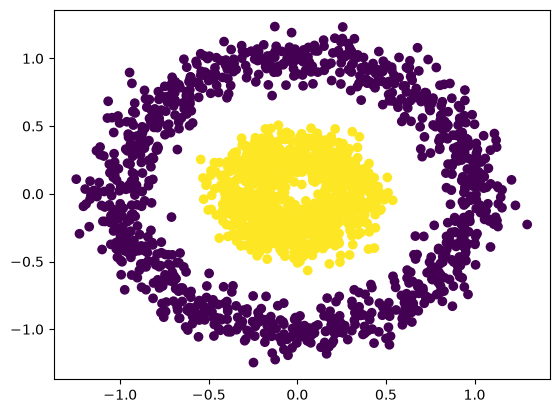

In [58]:
plt.scatter(X[:,0],X[:,1], c=y)

In [59]:
dbscan = DBSCAN(eps = 0.10)

In [60]:
dbscan.fit_predict(X)

array([0, 0, 1, ..., 0, 0, 0], shape=(2000,))

In [61]:
dbscan.labels_

array([0, 0, 1, ..., 0, 0, 0], shape=(2000,))

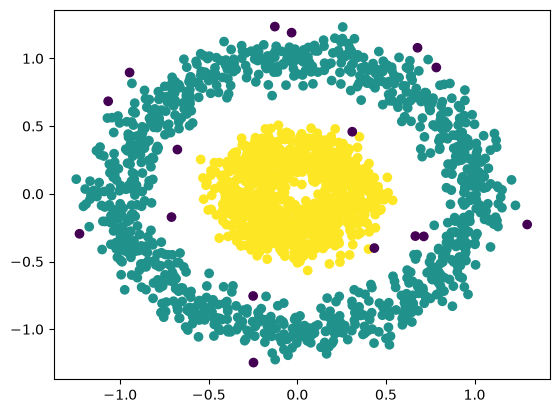

In [62]:
plt.scatter(X[:,0],X[:,1], c=dbscan.labels_)

In [63]:
from sklearn.neighbors import LocalOutlierFactor

In [64]:
clf = LocalOutlierFactor(n_neighbors=5)
clf.fit_predict(X)

array([1, 1, 1, ..., 1, 1, 1], shape=(2000,))

In [65]:
clf.negative_outlier_factor_

array([-1.0585773 , -0.9897374 , -1.01885878, ..., -0.95765733,
       -1.02504782, -1.15910169], shape=(2000,))

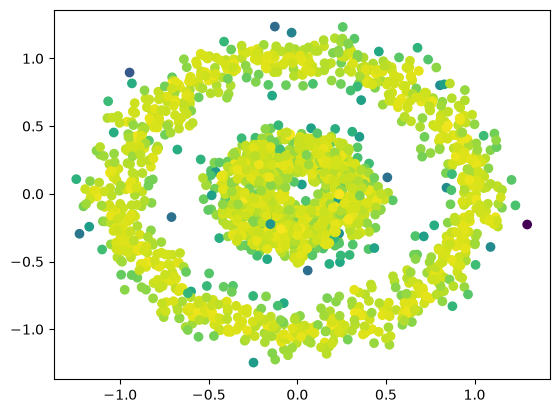

In [66]:
plt.scatter(X[:,0],X[:,1], c=clf.negative_outlier_factor_)

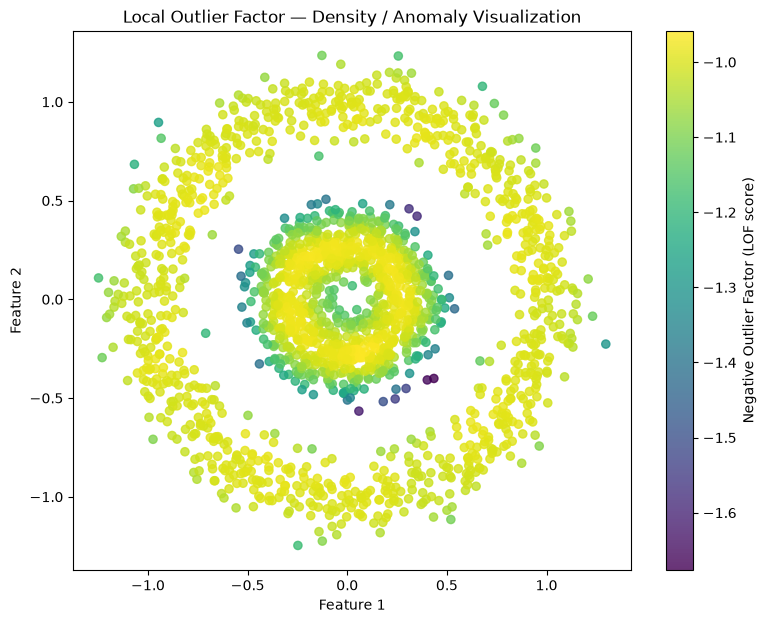

In [67]:
import matplotlib.pyplot as plt
from sklearn.neighbors import LocalOutlierFactor

# LOF model
clf = LocalOutlierFactor(n_neighbors=75)

# Fit + predict
y_pred = clf.fit_predict(X)

# LOF scores
lof_scores = clf.negative_outlier_factor_

# Plot
plt.figure(figsize=(9, 7))

scatter = plt.scatter(
    X[:, 0],
    X[:, 1],
    c=lof_scores,
    cmap="viridis",
    s=35,
    alpha=0.8
)

# Color scale
cbar = plt.colorbar(scatter)
cbar.set_label("Negative Outlier Factor (LOF score)")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Local Outlier Factor — Density / Anomaly Visualization")

plt.show()